In [1]:
import pandas as pd
import numpy as np
import os
import datetime as dt
import matplotlib.pyplot as plt
import xarray as xr
import lanczos_filter as lf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
%load_ext autoreload
%autoreload 2

# Descarga ERA

In [ ]:
import os
import cdsapi

# 1. Definir la ruta de la carpeta de destino
output_dir = "/home/jta/Documentos/articulo_planificacion/planificacion_energetica/data_era_ghi"

# Crear la carpeta si no existe
os.makedirs(output_dir, exist_ok=True)

# 2. Configurar el cliente de CDS
client = cdsapi.Client()
dataset = "reanalysis-era5-land"

# 3. Generar listas de años, meses y días
years = [str(year) for year in range(2000, 2025)]  # Genera del 2000 al 2024
months = [f"{m:02d}" for m in range(1, 13)]       # Genera ['01', '02', ..., '12']
days = [f"{d:02d}" for d in range(1, 32)]         # Genera ['01', '02', ..., '31']

# 4. Iterar año por año para evitar saturar la API
for year in years:
    print(f"--- Iniciando descarga del año {year} ---")
    
    # Definir el nombre y ruta completa del archivo de salida
    output_filename = os.path.join(output_dir, f"era5_land_ghi_{year}.nc")
    
    request = {
        "variable": ["surface_solar_radiation_downwards"],
        "year": year,      # Pide solo el año actual de la iteración
        "month": months,   # Incluye todos los meses del año
        "day": days,       # Incluye todos los días
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [13.5, -80, -6.5, 66.5]
    }
    
    try:
        # Pass el nombre del archivo directamente al método .download()
        client.retrieve(dataset, request).download(output_filename)
        print(f"Descarga completada con éxito: {output_filename}\n")
    except Exception as e:
        print(f"Error al descargar el año {year}: {e}\n")

print("Proceso de descarga finalizado.")

# Recurso hídrico

## Datos XM

In [ ]:
path = 'data'
files = os.listdir(path)
path_files = [os.path.join(path,file) for file in files if 'xlsx' in file]

In [ ]:
list_df = list()

for file in path_files:
    df = pd.read_excel(
        file,
        skiprows=3,
        parse_dates=True,
        index_col=0
    )
    list_df.append(df)

# Concatenacion datos
df_concat = pd.concat(list_df,axis=0)

In [ ]:
# Separacion datos por embalse
embalses = df_concat['Nombre Embalse'].unique()
dict_embalses = dict()

for embalse in embalses:
    mask = df_concat['Nombre Embalse'] == embalse
    df_embalse = df_concat[mask]
    dict_embalses[embalse] = df_embalse

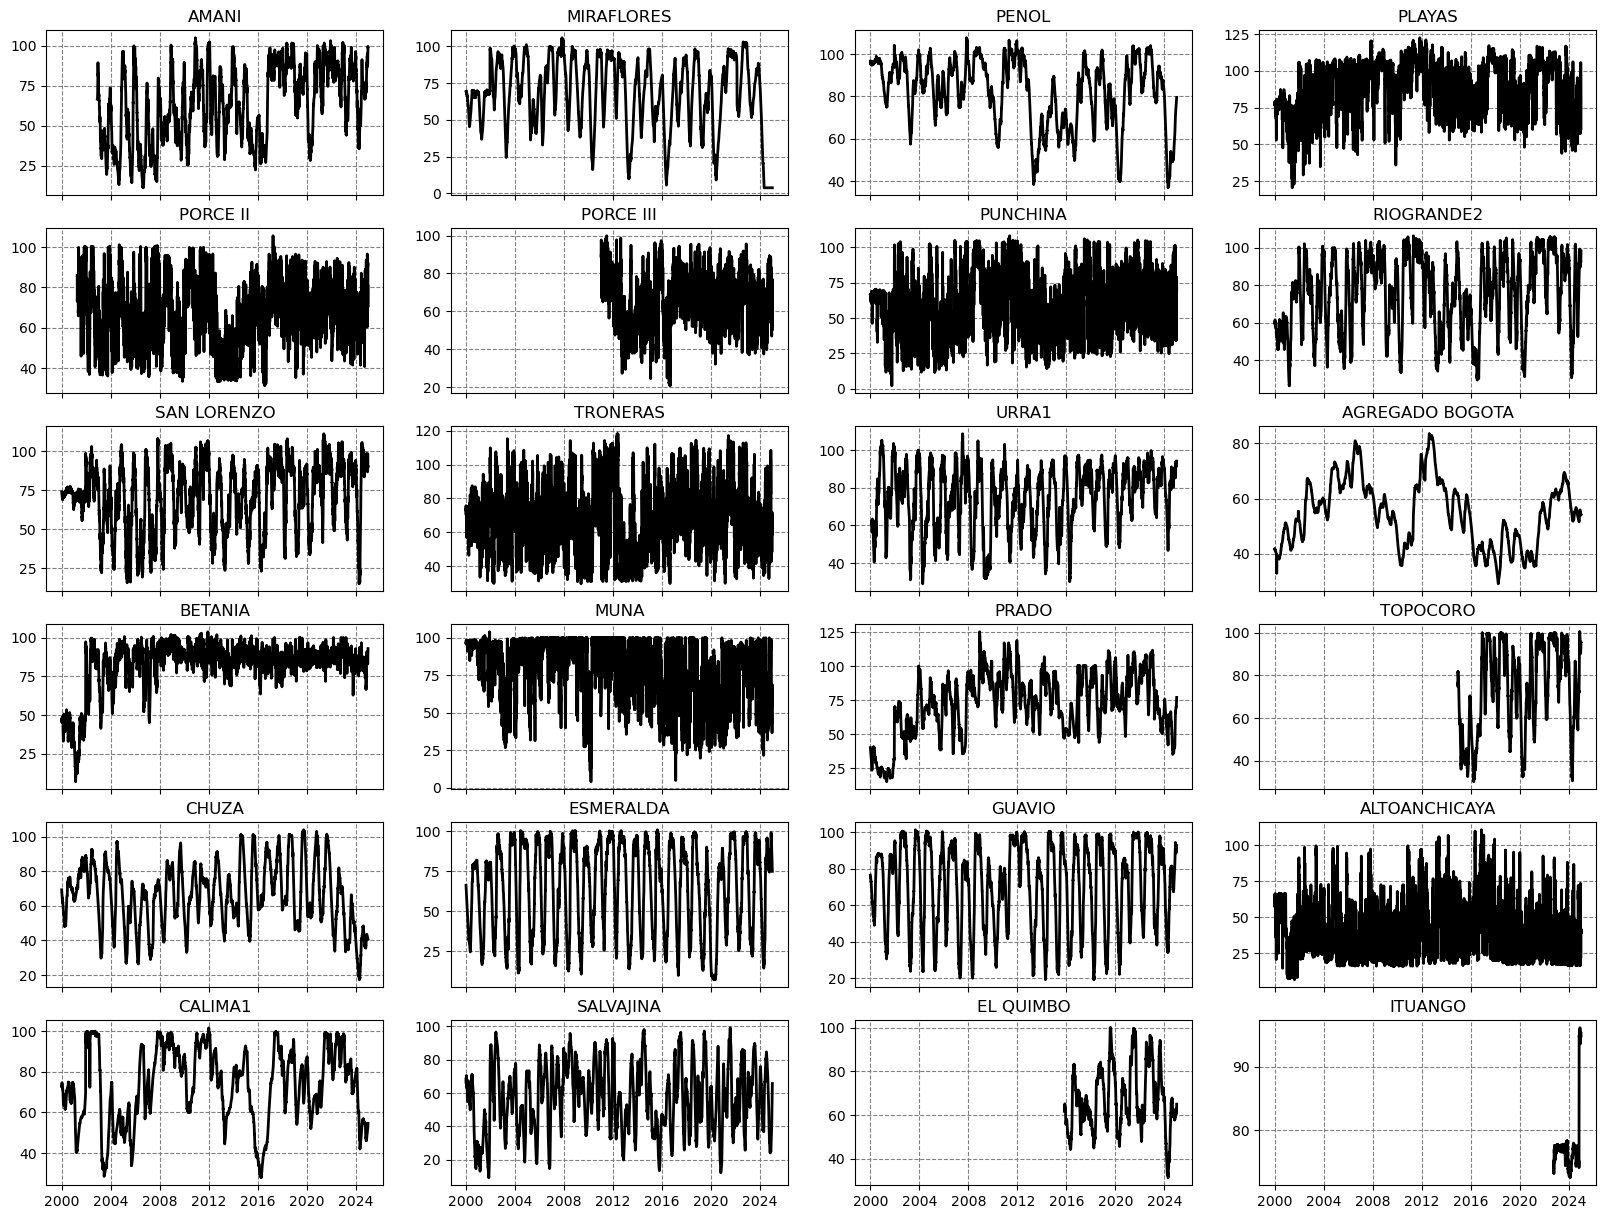

In [ ]:
# Revision consistencia de las series 
fig, axes = plt.subplots(
    nrows = 6,
    ncols = 4,
    figsize = (20,15),
    sharex=True
)
ax = axes.flatten()

idx = 0
for embalse,df in dict_embalses.items():

    df = df.sort_index()
    
    # Ploteo de los datos
    ax[idx].plot(
        df['Volumen %']*100,
        linewidth=2.0,
        color='black'
    )
    # Titulo
    ax[idx].set_title(embalse)
    # grilla
    ax[idx].grid(linestyle='--',color='grey')

    # Actualizacion subplot
    idx += 1

## Influencia del ENSO

In [71]:
# Lectura datos MEI
path = 'mei_mensual_2000_2024.csv'
df_mei = pd.read_csv(path,index_col='Date',parse_dates=True)

In [18]:
# Filtrar series de tiempo de cada embalse mediante el MEI

def clasificar_enso(
        df_mei,
        df,
        umbral
    ):
        
    # Lectura del dataframe con el oni

    df_clasificar = df.copy()
    #Columna que contiene los caudales
    columna = df_clasificar.columns[-1]
        
    # Inicializamos con "Neutral"
    df_mei['enso_phase'] = 'neutro'  
    for i in range(len(df_mei) - 4):
    # Tomamos una ventana de 5 meses consecutivos
        window = df_mei['MEI'].iloc[i:i+5]
        if all(window >= 0.5):
            df_mei.iloc[i:i+4, 1] = 'niño'
        elif all(window <= -0.5):
            df_mei.iloc[i:i+4, 1] = 'niña'
                
    # Clasificacion datos con el oni
    df_clasificar['month'] = df_clasificar.index.to_period('M')
    df_mei['month'] = df_mei.index.to_period('M')
    df_merged = pd.merge(
        df_clasificar, 
        df_mei, 
        on='month', 
        how='left'
    )
    df_merged.index = df_clasificar.index
        
    df_clasificado = df_merged[[columna,'enso_phase']]
    return df_clasificado

In [ ]:
df_embalse = dict_embalses['ALTOANCHICAYA']
df_embalse = df_embalse.sort_index()
df_clasificado = clasificar_enso(df_mei,df_embalse,5)


True

In [76]:
df_clasificado['Volumen %'] = df_clasificado['Volumen %']*100

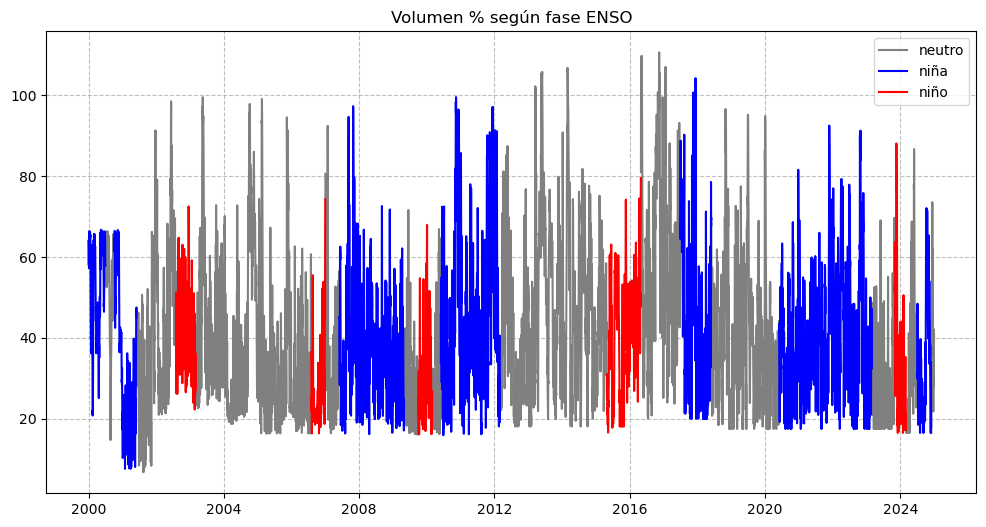

In [ ]:
# Ploteo de verificacion
mask_nina = df_clasificado['enso_phase'] == 'niña'
mask_nino = df_clasificado['enso_phase'] == 'niño'
mask_neutro = df_clasificado['enso_phase'] == 'neutro'
# dataframes 
import matplotlib.pyplot as plt
import numpy as np

# Cambié el figsize a (12, 6) porque para series de tiempo es mejor que sea más ancho que alto
plt.figure(figsize=(12, 6))

# .where() pone NaN donde la condición es falsa, cortando la línea automáticamente
plt.plot(
    df_clasificado['Volumen %'].where(mask_neutro), 
    color='grey', 
    label='neutro'
)
plt.plot(
    df_clasificado['Volumen %'].where(mask_nina), 
    color='blue', 
    label='niña'
)
plt.plot(
    df_clasificado['Volumen %'].where(mask_nino), 
    color='red', 
    label='niño'
)

plt.legend(loc='best')
plt.grid(
    linestyle='--', 
    color='grey', 
    alpha=0.5
)

## Comportamiento multianual del porcentaje bajo fase

In [83]:
dict_embalses_enso = dict()

for embalse,df in dict_embalses.items():

    df_embalse = df[['Volumen %']].sort_index()
    # clasificacion
    df_clasificado = clasificar_enso(
        df_mei=df_mei,
        df=df_embalse,
        umbral=5
    )
    dict_embalses_enso[embalse] = df_clasificado

In [85]:
# Definicion ciclo anual

def ciclo_anual(df):

    # Filtrado exploratorio por media
    df_resample = df.groupby(df.index.month).mean()
    return df_resample


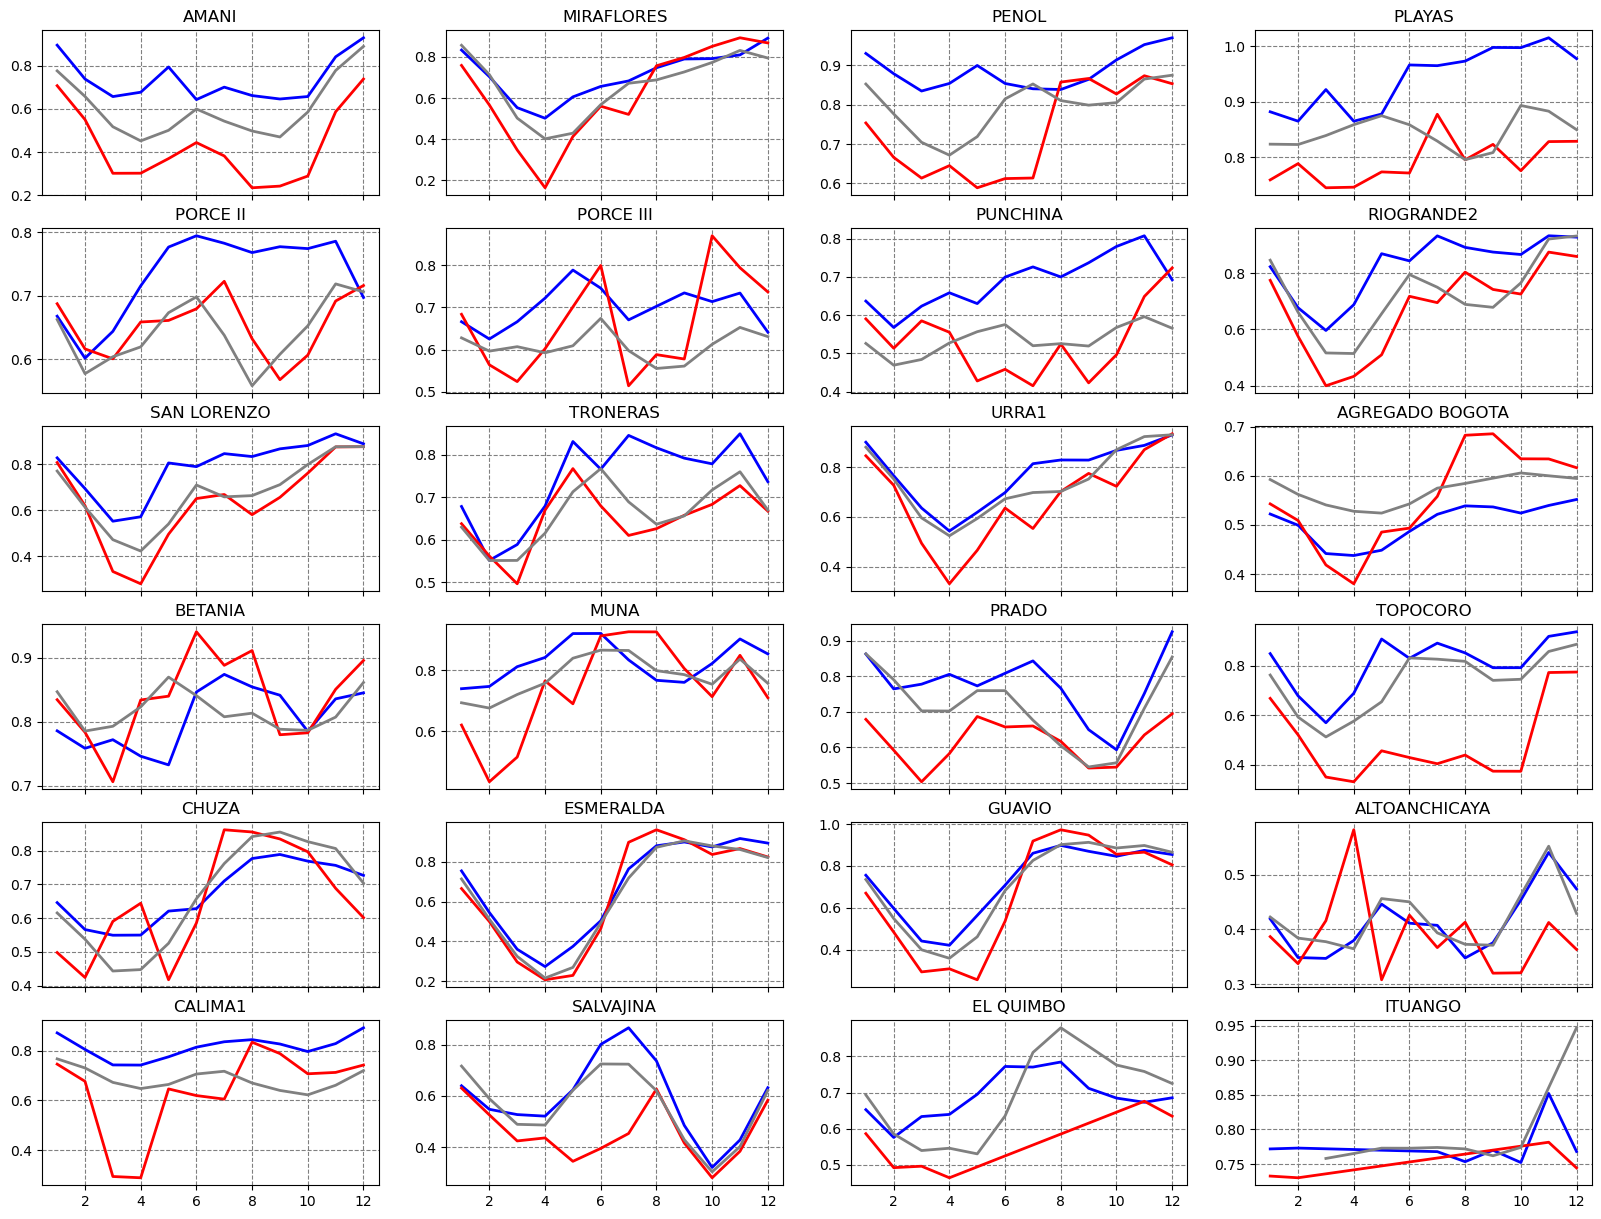

In [89]:
# Revision consistencia de las series 
fig, axes = plt.subplots(
    nrows = 6,
    ncols = 4,
    figsize = (20,15),
    sharex=True
)
ax = axes.flatten()

idx = 0
for embalse,df in dict_embalses_enso.items():

    # Mascaras 
    mask_nina = df['enso_phase'] == 'niña'
    mask_nino = df['enso_phase'] == 'niño'
    mask_neutro = df['enso_phase'] == 'neutro'

    # Filtrado
    df_neutro = df[mask_neutro]
    df_nino = df[mask_nino]
    df_nina = df[mask_nina]
    
    # Estimacion clico anual
    ciclo_nina = ciclo_anual(df_nina[['Volumen %']])
    ciclo_nino = ciclo_anual(df_nino[['Volumen %']])
    ciclo_neutro = ciclo_anual(df_neutro[['Volumen %']])

   # Ploteo de los ciclos
    ax[idx].plot(
        ciclo_nina,
        linewidth=2.0, 
        color='blue', 
        label='Niña'
    )
    ax[idx].plot(
        ciclo_nino,
        linewidth=2.0,
        color='red', 
        label='Niño'
    )
    ax[idx].plot(
        ciclo_neutro,
        linewidth=2.0,
        color='grey', 
        label='neutro'
    )
        # Titulo
    ax[idx].set_title(embalse)
    # grilla
    ax[idx].grid(linestyle='--',color='grey')

    # Actualizacion subplot
    idx += 1

# Recurso eólico

Paso a paso del filtro del recurso eólico:
- Transformación a densidad de potencia eólica
- Remoción de la estacionalidad mensual
- Uso de filtro de pasabanda para retener señal intraestacional
- Generación anomalías compuestas por Fase ENSO

In [3]:
def wpd(da,ro):

    wpd = 1/2 * (ro) * (da)**3

    return wpd

## Preparación de los datos

In [4]:
# Lectura de los datos y conversion a wpd
path_data_era = '/home/jta/Documentos/articulo_planificacion/era5_data_netcdf'
files = os.listdir(path_data_era)
# Almacenamiento de datos

dict_data_era = {
    'fecha':[],
    'path_file':[]
}

# Generacion dataframe que contiene fecha y archivo
for file in files:
    if 'nc' in file:
        file_name = file.split('_')
        year = file_name[2]
        month = file_name[3].split('.')[0]
        # Generacion fecha
        date = pd.to_datetime(
            year + '/' + month + '/' + '01', 
            yearfirst=True, 
            format='%Y/%m/%d'
        ).date()

        file_path = os.path.join(path_data_era,file)

        dict_data_era['fecha'].append(date)
        dict_data_era['path_file'].append(file_path)

df_data_era = pd.DataFrame(dict_data_era)
df_data_era = df_data_era.set_index('fecha',drop=True).sort_index()
df_data_era.index = pd.to_datetime(df_data_era.index)


In [5]:
# Arreglo para solo retener del 2000 en adelante
mask = df_data_era.index >= '1997'
df_data_slice = df_data_era[mask]

In [6]:
list_ds = list()
for file in df_data_slice['path_file']:
    ds = xr.open_dataset(file,engine='netcdf4')
    u_vel = ds['u100']
    v_vel = ds['v100']
    vel = np.sqrt(np.square(u_vel) + np.square(v_vel))
    # Estima la densidad de potencia con una densidad fija
    # Sujeto a mejoras
    # resampleo a mensual
    ds_vel_month = vel.resample(valid_time='ME').mean()
    list_ds.append(ds_vel_month)
# Generacion dataset
ds_concat = xr.concat(list_ds,dim='valid_time')

## Remoción de la estacionalidad

In [7]:
# Remoción de la estacionalidad
ciclo_anual = ds_concat.groupby("valid_time.month").mean("valid_time")
anom_viento = ds_concat.groupby("valid_time.month") - ciclo_anual

## Retención anomalías

In [8]:
coords = {
    'valid_time':anom_viento['valid_time'].values,
    'latitude':anom_viento['latitude'].values,
    'longitude':anom_viento['longitude'].values
}

In [9]:
# Aplicacion del filtro de Lanczos
N = 36
# Filtros de retención interanual
fc_rapida = 1/24
fc_lenta = 1/(7*12)

# Creacion de datarray vacio

time_dim = len(coords['valid_time']) - N * 2 
lat = len(coords['latitude'])
lon = len(coords['longitude'])
array_anom = np.zeros([time_dim,lat,lon])

for i in range(lat):
    for j in range(lon):

        # Extrae la serie de tiempo de un pixel
        time_series = anom_viento[:,i,j]
        # crea el filtro
        filtro = lf.lanczos(N,time_series,fc_rapida,fc_lenta)
        # Aplica el filtro
        data_filtrada = filtro.filtro_lanczos()
        # Almacenamiento en el array
        array_anom[:,i,j] = data_filtrada

In [10]:
# generacion Data array
coords['valid_time'] = coords['valid_time'][N:-N]

da_viento = xr.DataArray(
    data = array_anom,
    coords=coords
)

## Generación de anomalías compuestas

In [11]:
path = '/home/jta/Documentos/articulo_planificacion/planificacion_energetica/mei_mensual_2000_2024.csv'
df_mei = pd.read_csv(path,index_col='Date')
df_mei.index = pd.to_datetime(df_mei.index) + pd.offsets.MonthEnd(0)

In [12]:
df_clasificado = df_mei.copy()
#Columna que contiene los caudales
columna = df_clasificado.columns[-1]
    
# Inicializamos con "Neutral"
df_mei['enso_phase'] = 'neutro'  
for i in range(len(df_mei) - 4):
# Tomamos una ventana de 5 meses consecutivos
    window = df_mei['MEI'].iloc[i:i+5]
    if all(window >= 0.5):
        df_mei.iloc[i:i+4, 1] = 'niño'
    elif all(window <= -0.5):
        df_mei.iloc[i:i+4, 1] = 'niña'

In [13]:
fases = df_mei['enso_phase'].unique()

In [25]:
# Arreglo de los vectore u y v para plotearlos
list_ds = list()
for file in df_data_slice['path_file']:
    ds = xr.open_dataset(file,engine='netcdf4')
    ds_slice = ds[['u100','v100']]

    ds_vel_month = ds_slice.resample(valid_time='ME').mean()
    list_ds.append(ds_vel_month)
# Generacion dataset
ds_vectors = xr.concat(list_ds,dim='valid_time')

In [75]:
# Estimacion intervalos
vals = list()
for idx_row, fase in enumerate(fases):
    # filtro de fases
    mask = df_mei['enso_phase'] == fase
    df_filtrado = df_mei[mask]

    mask = da_viento['valid_time'].isin(df_filtrado.index)
    da_slice = da_viento[mask]
    anom_seasons = da_slice.groupby('valid_time.season').mean()

    max_val = anom_seasons.max().values
    min_val = np.abs(anom_seasons.min().values)
    vals.append(max_val)
    vals.append(min_val)

max_global = np.max(vals)
intervalos = np.round(np.linspace(-max_global,max_global,11),2)

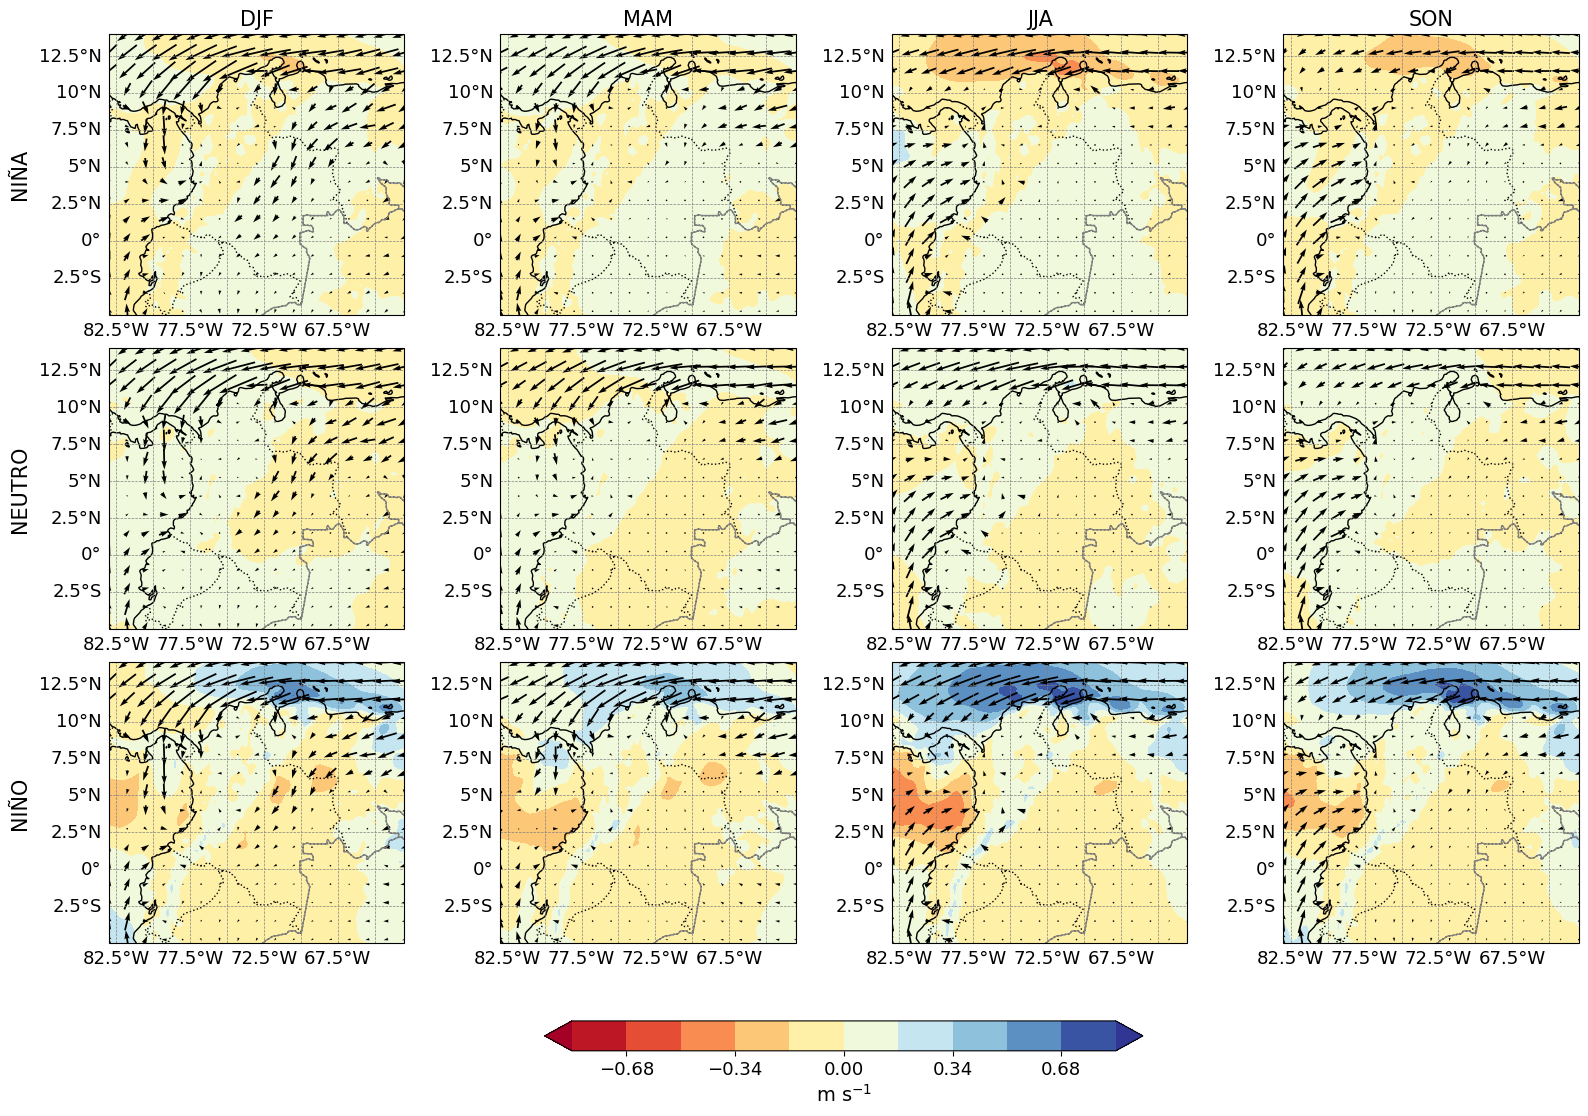

In [77]:
# Figuras

path_guardado = '/home/jta/Documentos/articulo_planificacion/planificacion_energetica'
fig_name = 'anomalias_enso_vel_viento.jpg'
file_name = os.path.join(path_guardado,fig_name)

seasons = ['DJF', 'MAM','JJA', 'SON']

# latitud y longitud
lat = np.array(coords['latitude'])
lon = np.array(coords['longitude'])

fig, axes = plt.subplots(
    nrows=3, 
    ncols=4, 
    subplot_kw={'projection':ccrs.PlateCarree()},
    figsize=(16, 11),
    constrained_layout=True
)

step = 5
# Dirección del viento fase
lat_quiver = np.array(coords['latitude'])[::step]
lon_quiver = np.array(coords['longitude'])[::step]
for idx_row, fase in enumerate(fases):

    # filtrado de los datos
    mask = df_mei['enso_phase'] == fase
    df_filtrado = df_mei[mask]

    # mask_ds = da_vectors['valid_time'].isin(df_filtrado.index)
    ds_vectors_slice = ds_vectors.sel(valid_time=df_filtrado.index)
    vectors_season = ds_vectors_slice.groupby('valid_time.season').mean()
    
    # Anomalias

    mask = da_viento['valid_time'].isin(df_filtrado.index)
    da_slice = da_viento[mask]
    anom_seasons = da_slice.groupby('valid_time.season').mean()

    for idx_col, season in enumerate(seasons):

        # Selecciona las anomalias de interes
        anom_season = anom_seasons.sel(season=season) 
        # seleccionar la temporada correspondiente ANTES de submuestrear
        u_season = vectors_season['u100'].sel(season=season)
        v_season = vectors_season['v100'].sel(season=season)

        u = u_season[::step, ::step]   # ahora sí (lat, lon)
        v = v_season[::step, ::step]
        vel = np.sqrt(u**2 + v**2)

        # Add coastlines and other geographical features
        ax = axes[idx_row,idx_col]
        ax.coastlines()
        ax.add_feature(
            cfeature.BORDERS, 
            linestyle=':'
        )
        ax.add_feature(
            cfeature.STATES, 
            edgecolor='gray'
        )

        gl = ax.gridlines(
            draw_labels=True, 
            color='gray', 
            linestyle='--', 
            linewidth=0.5,
        )

        if idx_row == 0:
            ax.set_title(season,fontsize=15)
        
        if idx_col == 0:
            ax.text(
                -0.30, 0.5, 
                fase.upper(),
                va='center', 
                ha='center',
                rotation='vertical',
                rotation_mode='anchor',
                transform=ax.transAxes,
                fontsize=15
            )


        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = True


        # Tamaño de las etiquetas
        gl.xlabel_style = {'size': 13} 
        gl.ylabel_style = {'size': 13}
  
        # Grafico de los contornos de humedad

        contour = ax.contourf(
            lon,lat,anom_season,
            transform=ccrs.PlateCarree(),
            cmap='RdYlBu',
            levels=intervalos, # Ajusta el número de niveles para suavidad
            extend='both'
        ) # Para extender el rango del colormap si los datos van más allá de los niveles        
        # Grafico de las flechas de transporte

        quiver = ax.quiver(
            lon_quiver,
            lat_quiver, 
            u, v,
            transform=ccrs.PlateCarree(),
            scale_units='xy',
            width=0.006,
            pivot='mid',
            scale=5,
            color='black',
            clim=(vel.min(),vel.max())
        )

cbar = fig.colorbar(
    contour,
    ax=axes.ravel().tolist(),   # todos los ejes comparten la barra
    orientation='horizontal',
    shrink=0.4,
    pad=0.05
)

cbar.set_label(r'$\text{m}~\text{s}^{-1}$', fontsize=14)
cbar.ax.tick_params(labelsize=13)


# Igualar el tamaño del segundo plot con el del primero

plt.savefig(
    file_name,
    dpi=600,
    bbox_inches='tight'
)
plt.show()



# Recurso solar